## Training result comparison
Experiments to compare:
- Fine-tuning experiment 04 (lr=1e-3)
- Fine-tuning experiment 06 (lr=1e-3, add lr scheduler2)
- Fine-tuning experiment 07 (lr=1e-3, add lr scheduler)
- Fine-tuning experiment 08 (lr=1e-3, add ReduceLROnPlateau)

## Setup
Set up file system for the datset(using Google Drive), dagshub and MLflow

In [1]:
# Install dependencies
%%capture
%pip install -q dagshub[jupyter]

In [2]:
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

# Set up dagshub
!dagshub login
import dagshub
TOKEN = dagshub.auth.get_token()

Mounted at /content/drive
                                ❗❗❗ AUTHORIZATION REQUIRED ❗❗❗                                


Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=94e63883-8315-43b5-9de6-0c8eb50a6d58&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=a9461f5f4ea4e5ee037cb0503c8ee97e4474b0aa4cec7f20e3a5294ea3ece161


⠇ Waiting for authorization
✅ OAuth token added


Accessing as chengzwk

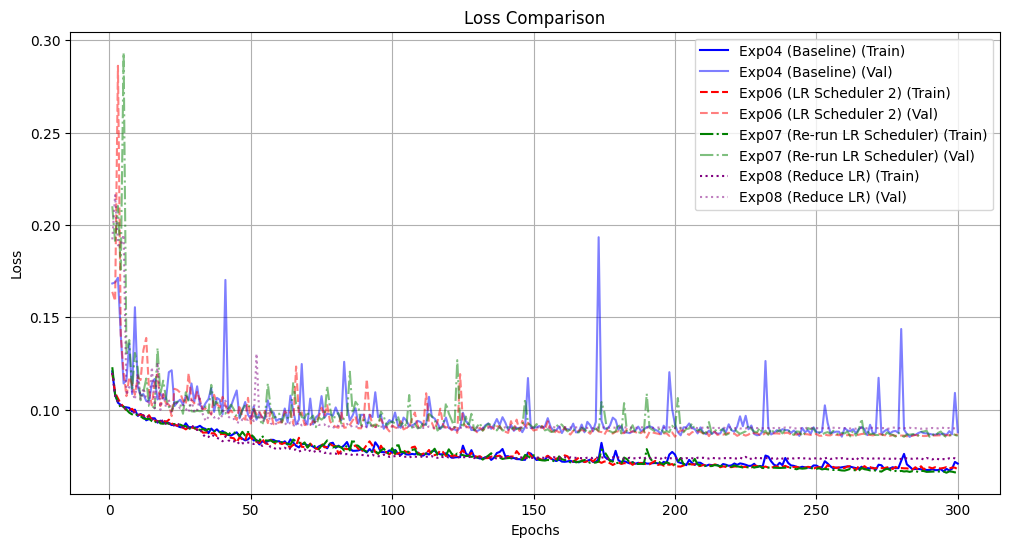

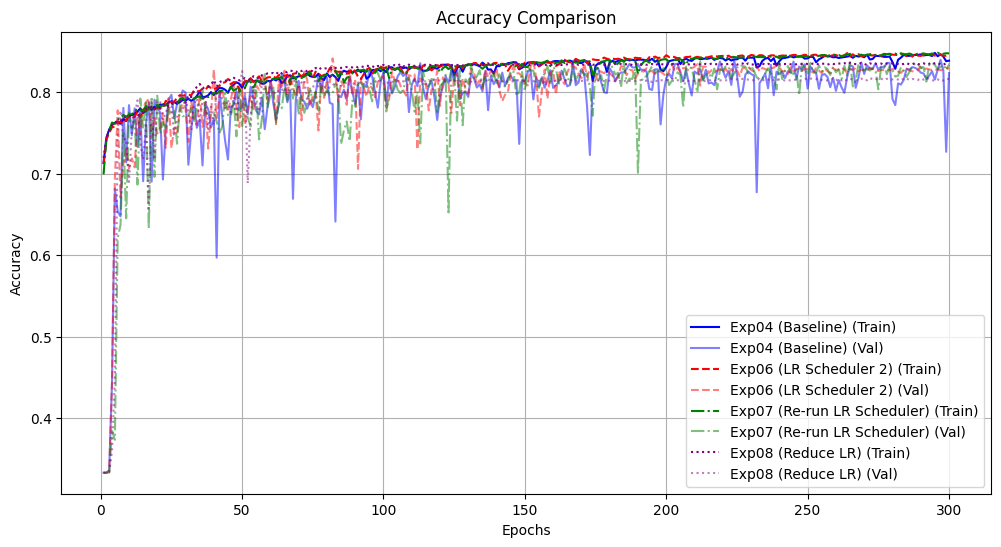

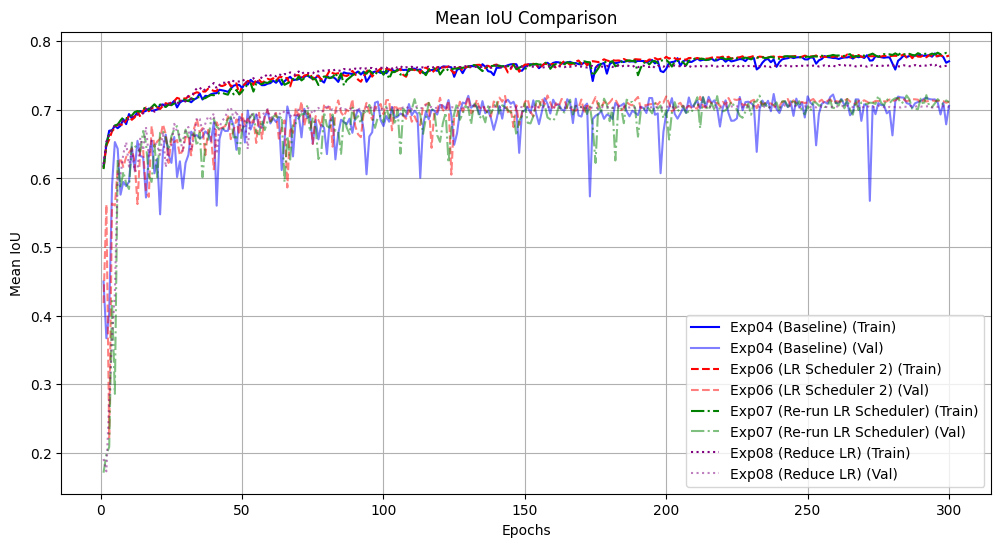

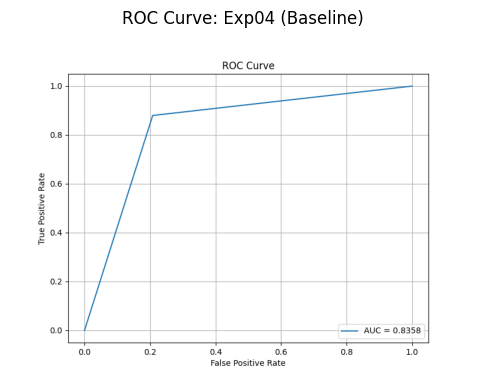

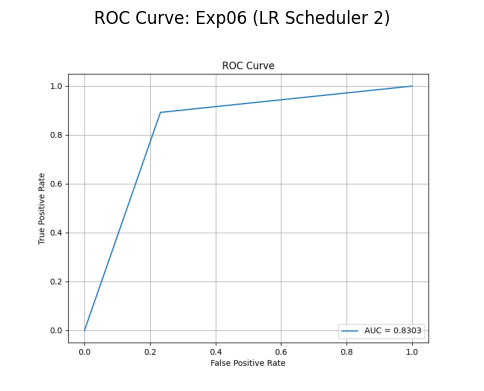

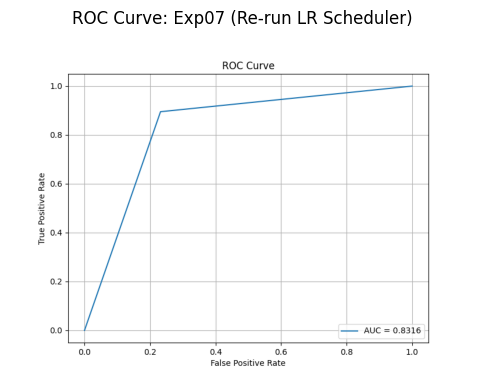

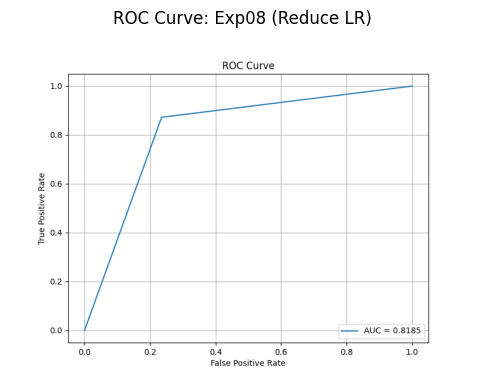

In [3]:
import os
import pickle
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Define experiment labels
experiments = {
    "Exp04 (Baseline)": "experiment04_leave_it_training",
    "Exp06 (LR Scheduler 2)": "experiment06_leave_it_training_lrscheduler2",
    "Exp07 (Re-run LR Scheduler)": "experiment07_rerun_leave_it_training_lrscheduler",
    "Exp08 (Reduce LR)": "experiment08_leave_it_training_reducelr"
}

# Base directory for results
base_dir = "/content/drive/My Drive/finetuning_experiment_results"

# Load histories
def load_history(filepath):
    with open(filepath, 'rb') as f:
        return pickle.load(f)

histories = {label: load_history(os.path.join(base_dir, exp, "unet_training_history.pkl")) for label, exp in experiments.items()}

# Define colors for plots
colors = ['blue', 'red', 'green', 'purple']
linestyles = ['-', '--', '-.', ':']

# Function to plot multiple experiments
def plot_experiments(histories, train_metric, val_metric, title, ylabel):
    plt.figure(figsize=(12, 6))
    for (label, history), color, linestyle in zip(histories.items(), colors, linestyles):
        epochs = np.arange(1, len(history[train_metric]) + 1)
        plt.plot(epochs, history[train_metric], linestyle, color=color, label=f'{label} (Train)')
        plt.plot(epochs, history[val_metric], linestyle, color=color, alpha=0.5, label=f'{label} (Val)')

    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot Loss, Accuracy, and IoU
plot_experiments(histories, "loss", "val_loss", "Loss Comparison", "Loss")
plot_experiments(histories, "accuracy", "val_accuracy", "Accuracy Comparison", "Accuracy")
plot_experiments(histories, "binary_io_u", "val_binary_io_u", "Mean IoU Comparison", "Mean IoU")

# Load and display ROC curves
def show_image(image_path, title):
    img = Image.open(image_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(title)
    plt.show()

for label, exp in experiments.items():
    roc_path = os.path.join(base_dir, exp, "ROC_curve.png")
    show_image(roc_path, f"ROC Curve: {label}")


In [4]:
import pandas as pd

# Define test results for each experiment
test_results = {
    "experiment04_leave_it_training": {
        "Loss": 0.0903,
        "Accuracy": 0.8060,
        "Precision": 0.8714,
        "Recall": 0.8798,
        "F1 Score": 0.8755,
        "Mean IoU": 0.7213,
        "IoU for class 1": 0.7786,
        "AUC": 0.8358
    },
    "experiment06_leave_it_training_lrscheduler2": {
        "Loss": 0.0922,
        "Accuracy": 0.8193,
        "Precision": 0.8605,
        "Recall": 0.8923,
        "F1 Score": 0.8761,
        "Mean IoU": 0.7174,
        "IoU for class 1": 0.7796,
        "AUC": 0.8303
    },
    "experiment07_rerun_leave_it_training_lrscheduler": {
        "Loss": 0.0913,
        "Accuracy": 0.8202,
        "Precision": 0.8608,
        "Recall": 0.8951,
        "F1 Score": 0.8776,
        "Mean IoU": 0.7197,
        "IoU for class 1": 0.7819,
        "AUC": 0.8316
    },
    "experiment08_leave_it_training_reducelr": {
        "Loss": 0.0966,
        "Accuracy": 0.8024,
        "Precision": 0.8559,
        "Recall": 0.8723,
        "F1 Score": 0.8640,
        "Mean IoU": 0.6976,
        "IoU for class 1": 0.7606,
        "AUC": 0.8185
    }
}

# Convert to DataFrame
df_results = pd.DataFrame(test_results)

# Compute changes relative to baseline (experiment04)
baseline = df_results["experiment04_leave_it_training"]
df_changes = df_results.subtract(baseline, axis=0)

# Display results
print("\nTest Set Results:")
display(df_results.T)

print("\nChanges Compared to Baseline (experiment04_leave_it_training):")
display(df_changes.T)



Test Set Results:


,Loss,Accuracy,Precision,Recall,F1 Score,Mean IoU,IoU for class 1,AUC
experiment04_leave_it_training,0.0903,0.8060,0.8714,0.8798,0.8755,0.7213,0.7786,0.8358
experiment06_leave_it_training_lrscheduler2,0.0922,0.8193,0.8605,0.8923,0.8761,0.7174,0.7796,0.8303
experiment07_rerun_leave_it_training_lrscheduler,0.0913,0.8202,0.8608,0.8951,0.8776,0.7197,0.7819,0.8316
experiment08_leave_it_training_reducelr,0.0966,0.8024,0.8559,0.8723,0.8640,0.6976,0.7606,0.8185



Changes Compared to Baseline (experiment04_leave_it_training):


,Loss,Accuracy,Precision,Recall,F1 Score,Mean IoU,IoU for class 1,AUC
experiment04_leave_it_training,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
experiment06_leave_it_training_lrscheduler2,0.0019,0.0133,-0.0109,0.0125,0.0006,-0.0039,0.0010,-0.0055
experiment07_rerun_leave_it_training_lrscheduler,0.0010,0.0142,-0.0106,0.0153,0.0021,-0.0016,0.0033,-0.0042
experiment08_leave_it_training_reducelr,0.0063,-0.0036,-0.0155,-0.0075,-0.0115,-0.0237,-0.0180,-0.0173


## Conclusion
- Results experiment 06 ~ 07 > 04(baseline) > 08
- In val loss and val accuracy, experiment 06's result is rougly the same as experiment 07, but is more stable
- In test metrics, experiment 07 is slightly better



## Commit notebook to dagshub

In [5]:
commit_message = "Analyze and cmpare training result for experiment 08 (large learning rate with reducelr)"

In [ ]:
from dagshub.notebook import save_notebook

repo = "chengzwk/omdena-frankfurt-ugs-unet"
branch = "fine-tuning"
notebook_path = "finetuning_experiment08_result_comparison"

save_notebook(
    repo=repo,
    branch=branch,
    path=notebook_path,
    commit_message=commit_message,
    versioning="git"
    )